## Prompt
> Find all structural analogues of Lapatinibe across all databases. Retain quinazoline core and modify all its decorations (both branches attached to the quinazoline must be modified, not just one) while keeping shape and electrostatic possible as high as possible. Make then grid with 5x5 most similar molecules and their pricing. Calculate UMAP. export as csv file with head - id, smiles, vendor, email, price.

### Step 1 — get lapatinib's structure

"Lapatinib" is an INN/generic drug name, not a systematic IUPAC name, so per the routing rule in `note.md` (Issue 7), OPSIN is tried first and expected to fail, then falls back to PubChem's name search (which cross-references synonym databases OPSIN doesn't have).

In [1]:
import httpx
import urllib.parse
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

NAME = "Lapatinib"

encoded = urllib.parse.quote(NAME, safe="")
opsin = httpx.get(f"https://www.ebi.ac.uk/opsin/ws/{encoded}.json", timeout=20).json()
print(f"OPSIN status for {NAME!r}: {opsin['status']}")

if opsin["status"] == "SUCCESS":
    QUERY = opsin["smiles"]
else:
    pubchem = httpx.post(
        "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/property/CanonicalSMILES,MolecularFormula/JSON",
        data={"name": NAME},
        timeout=20,
    ).json()
    props = pubchem["PropertyTable"]["Properties"][0]
    QUERY = props.get("CanonicalSMILES") or props["ConnectivitySMILES"]
    print(f"PubChem CID {props['CID']}, formula {props['MolecularFormula']}")

mol = Chem.MolFromSmiles(QUERY)
assert rdMolDescriptors.CalcMolFormula(mol) == "C29H26ClFN4O4S"
print(f"Lapatinib SMILES: {QUERY}")

OPSIN status for 'Lapatinib': FAILURE


PubChem CID 208908, formula C29H26ClFN4O4S
Lapatinib SMILES: CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl


### Step 2 — analogues across all databases: retain quinazoline, both shape and ESP high

"Keep shape and electrostatic as high as possible" needs a real per-candidate score for *both* metrics on the *same* molecule. This time — unlike the earlier scaffold-hop examples that wanted one metric low and the other high — intersecting two independent "most similar" searches is the *correct* technique, not the anti-pattern documented in `guidelines.md` (Step 4): that anti-pattern is specifically about finding molecules that are *dissimilar* by one metric, which can never appear in a "most similar" list. Here we want molecules similar by *both* metrics simultaneously, which intersecting two "most similar" lists finds exactly.

Quinazoline retention is checked **locally with RDKit** on every hit's SMILES rather than via `dmc.substructure()` — this sidesteps needing to know or care which of the 7 databases support substructure search at all (`enamine-real-v5a` doesn't, see Issue 3), since the check runs uniformly on SMILES already returned by the (always-available) similarity search.

**Both branches off the quinazoline must actually be modified, not just one.** The first version of this notebook only checked for quinazoline retention and ranked by shape+ESP — and every top result kept lapatinib's chloro-fluorobenzyloxy-aniline branch completely unchanged, varying only the other (sulfonamide) branch. This isn't a bug in the query, it's what ranking by *overall* 3D similarity does by construction: that branch contributes more to the molecule's shape/electrostatics, so changing it drops a candidate out of the high-shape+ESP pool faster than changing the smaller branch does. `Chem.ReplaceCore` splits each molecule into its two R-group fragments at the quinazoline core; a candidate is only kept if **neither** fragment matches lapatinib's own corresponding fragment — i.e. both branches genuinely differ. This drops the pool from 339 to 245, still comfortably enough for the 5x5 grid and a useful CSV.

In [2]:
from deepmedchem import Client

QUINAZOLINE = Chem.MolFromSmarts("c1ncnc2ccccc12")
LIMIT = 200

with Client() as client:
    databases = [lib["database_id"] for lib in client.catalog()["libraries"]]

    rows = []
    for db in databases:
        shape_r = client.search(QUERY, database=db, method="shape", limit=LIMIT)
        esp_r = client.search(QUERY, database=db, method="esp", limit=LIMIT)
        shape_by_id = {h.product_id: h for h in shape_r.hits}
        esp_by_id = {h.product_id: h for h in esp_r.hits}
        common_ids = set(shape_by_id) & set(esp_by_id)

        kept = 0
        for pid in common_ids:
            hit = shape_by_id[pid]
            mol = Chem.MolFromSmiles(hit.smiles)
            if mol is None or not mol.HasSubstructMatch(QUINAZOLINE):
                continue
            kept += 1
            rows.append({
                "database": db,
                "id": pid,
                "smiles": hit.smiles,
                "shape": hit.score,
                "esp": esp_by_id[pid].score,
                "price": hit.price,
            })
        print(f"{db}: shape/esp overlap={len(common_ids)}  quinazoline-retaining={kept}")

def branch_fragments(smiles):
    mol = Chem.MolFromSmiles(smiles)
    frags = Chem.ReplaceCore(mol, QUINAZOLINE, labelByIndex=True)
    return {Chem.MolToSmiles(p) for p in Chem.GetMolFrags(frags, asMols=True)}

lapatinib_branches = branch_fragments(QUERY)
before = len(rows)
rows = [r for r in rows if not (lapatinib_branches & branch_fragments(r["smiles"]))]
print(f"\nrequiring both branches to differ from lapatinib's: {before} -> {len(rows)}")

for row in rows:
    row["combined_score"] = (row["shape"] + row["esp"]) / 2

rows.sort(key=lambda r: r["combined_score"], reverse=True)
print(f"total quinazoline-retaining, both-branches-modified analogues (high shape AND high ESP): {len(rows)}")

cheminfinita-2026-02: shape/esp overlap=72  quinazoline-retaining=4


d2b-spacem1: shape/esp overlap=147  quinazoline-retaining=146


enamine-real-v5a: shape/esp overlap=145  quinazoline-retaining=6


freedom-space-5: shape/esp overlap=94  quinazoline-retaining=94


synple-explore-2025-10: shape/esp overlap=91  quinazoline-retaining=86


synple-synple-2025-10: shape/esp overlap=33  quinazoline-retaining=3


vast-2026-h2: shape/esp overlap=111  quinazoline-retaining=0

requiring both branches to differ from lapatinib's: 339 -> 245
total quinazoline-retaining, both-branches-modified analogues (high shape AND high ESP): 245


### Step 3 — 5x5 grid of the 25 best analogues (shape+ESP), with pricing

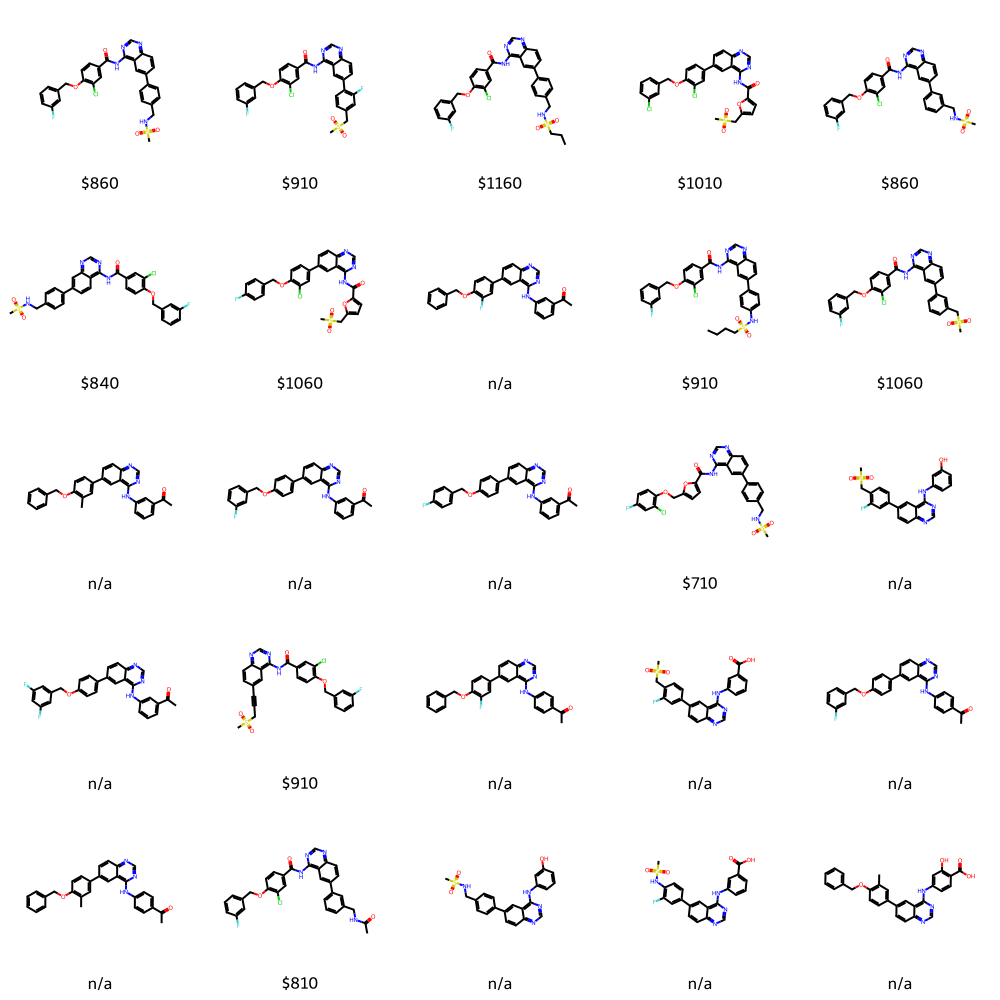

In [3]:
from rdkit.Chem import Draw

top25 = rows[:25]
mols = [Chem.MolFromSmiles(r["smiles"]) for r in top25]
legends = [
    f"${r['price']}" if r["price"] is not None else "n/a"
    for r in top25
]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=legends)

### Step 4 — UMAP over all analogues

ECFP4 (Morgan) fingerprints, the standard input for a chemical-space UMAP embedding (no single metric was specified as "the main one" this time, unlike `006`). Colored by the combined shape+ESP score — a single-hue sequential blue ramp, light→dark, reusing the same validated ramp as `006` (`node scripts/validate_palette.js` from the `dataviz` skill).

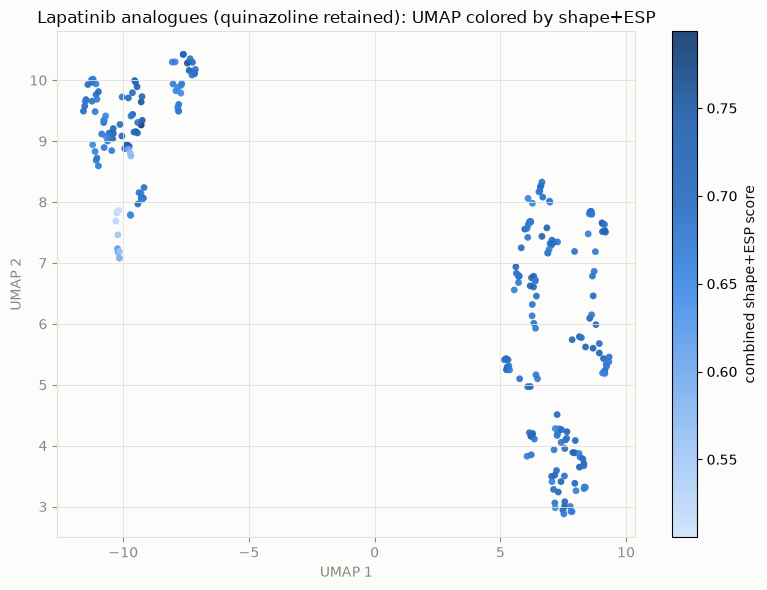

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
import umap

MORGAN_GENERATOR = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

fps = []
for row in rows:
    mol = Chem.MolFromSmiles(row["smiles"])
    fp = MORGAN_GENERATOR.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fps.append(arr)
fps = np.array(fps)

embedding = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1, metric="jaccard").fit_transform(fps)
for row, (x, y) in zip(rows, embedding):
    row["umap_1"], row["umap_2"] = x, y

# Single-hue blue sequential ramp (validated), light->dark = low->high combined score.
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#1c5cab", "#0d366b"]
cmap = mcolors.LinearSegmentedColormap.from_list("blue_seq", BLUE_RAMP)

scores = [r["combined_score"] for r in rows]
fig, ax = plt.subplots(figsize=(8, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
sc = ax.scatter(
    [r["umap_1"] for r in rows], [r["umap_2"] for r in rows],
    c=scores, cmap=cmap, s=24, linewidths=0, alpha=0.9,
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("combined shape+ESP score", color="#0b0b0b")
ax.set_title("Lapatinib analogues (quinazoline retained): UMAP colored by shape+ESP", color="#0b0b0b")
ax.set_xlabel("UMAP 1", color="#898781")
ax.set_ylabel("UMAP 2", color="#898781")
ax.tick_params(colors="#898781")
for spine in ax.spines.values():
    spine.set_color("#e1e0d9")
ax.grid(color="#e1e0d9", linewidth=0.6)
fig.tight_layout()
plt.show()

### Step 5 — export CSV: id, smiles, vendor, email, price

`vendor`/`email` come from `deepmedchem.ordering.procurement_contacts()` — the same built-in database-to-vendor registry the CLI's `dmc order --get-quote` uses, not invented here.

In [5]:
import csv
from deepmedchem.ordering import procurement_contacts

contacts = procurement_contacts()

CSV_PATH = "examples/prompts/008_lapatinib_analogues.csv"
with open(CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "smiles", "vendor", "email", "price"])
    for row in rows:
        contact = contacts[row["database"].casefold()]
        writer.writerow([row["id"], row["smiles"], contact.name, contact.email, row["price"]])

print(f"wrote {len(rows)} rows to {CSV_PATH}")

wrote 245 rows to examples/prompts/008_lapatinib_analogues.csv
